# An Introduction to FEAST v3.1

FEAST v3.1 is the Decemeber 2020 release of the Fugitive Emmissions Abatement Simulation Toolkit (FEAST). The toolkit simulates emissions from natural gas fields and the efficacy of leak detection and repair programs. This tutorial gives an example of how to generate an example emissions scenario in FEAST 3.1, define LDAR programs and analyze results. The tutorial is interactive, so feel free to experiment with the code cells and discover how your changes affect the results.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import os
import copy
import feast
import pickle
from multiprocessing import Pool

# Defining an emission scenario
FEAST requires all potential emission sources to be declared as Components. Components are characterized by their emission production rate, emission size distribution, and the fraction of components expected to be emitting at the beginning of the simulation. In order to improve transparency, FEAST 3.1 does not have a "default" scenario. All emitters must be defined directly in order to run the simulation.

## Define fugitive components
For this example, we will define exactly one type of component: a fugitive emitter. Additional types of components can be created in the same way. Venting components (that is, components that are intended to produce emissions) can be created by setting the "base_reparable" variable to False. In real production sites vented and fugitive emissions will both be present.

In [112]:
comp_fug = feast.EmissionSimModules.infrastructure_classes.Component(
    name='Fugitive emitters',
    emission_data_path='ExampleData/DataObjectInstances/production_emissions.p',
    emission_per_comp=0.00231,  # Fraction of components expected to be emitting at the beginning of the simulation.
    # emission_production_rate is set to about 5 new emissions per well per year
    emission_production_rate=5.4 / 650 / 365,  # number of new emissions per component per day
    repair_cost_path='ExampleData/DataObjectInstances/fernandez_leak_repair_costs_2006.p',
    base_reparable=True
)

## Define a production Site
A site is made of a collection of components. The components are stored in the variable comp_dict. The analyst may include many component types in the comp_dict.

Using the copy library is good practice if a component type is going to be reused in multiple sites to avoid shared parameters.

In [113]:
wells_per_site = 2
comps_per_well = 650
basic_site = feast.EmissionSimModules.infrastructure_classes.Site(
    name='basic site',
    comp_dict={
        # ------ The number of components is proportional to the number of wells, ind2
        'Fugitive ': {'number': comps_per_well * wells_per_site,
                     'parameters': copy.deepcopy(comp_fug)},
    },
)

## Define a Time object
FEAST requires the simulation time settings to be declared in a time object.

In [114]:
time = feast.EmissionSimModules.simulation_classes.Time(delta_t=1, end_time=365)

## Define a GasField
All of the sites to be simulated must be collected into a dict and then passed to a GasField object. As of FEAST 3.1, a GasField object may also contain meteorological data.

In [115]:
site_dict = {
    'basic site': {
        'number': 100, # The number of basic_site instances to simulate in the gas_field
        'parameters': basic_site
    }
    # If additional site types are needed, they should be added here as separate dict entries
}
gas_field = feast.EmissionSimModules.infrastructure_classes.GasField(
    sites=site_dict,
    time=time,
    met_data_path='ExampleData/TMY-DataExample.csv'
)

# Define LDAR programs
LDAR programs are made of detection methods, repair methods, and the connections between them. The first step in creating LDAR programs is defining detection and repair methods.

## Define a repair method
A repair method takes one input parameter: the delay (days) between when an emission is detected and when it is repaired.

In [116]:
rep3 = feast.DetectionModules.repair.Repair(repair_delay=3)

## Define detection methods
Detection methods accept a variety of variables that depend on the type of detection method to be simulated. In all cases, a detection method requires a set of conditions to be specified where the probability of detection (PoD) is known. Three examples are demonstrated below.

In [117]:
# An OGI-like example where the PoD depends on emission rate only.
def make_ogi(dispatch_obj):
    points = np.array([0.5, 1, 2, 3, 7]) * 0.01157 # g/s
    probs = np.array([0, 0.25, 0.5, 0.75, 1])
    ogi = feast.DetectionModules.comp_survey.CompSurvey(
        time,
        survey_interval=180, # days
        survey_speed=500, # comps/hr
        ophrs={'begin': 8, 'end': 17},
        labor=400, # $/hr
        detection_variables={'flux': 'mean'},
        detection_probability_points=points,  # g/s
        detection_probabilities=probs,
        dispatch_object=copy.deepcopy(dispatch_obj),
        site_queue=[],
    )
    return ogi
ogi = make_ogi(rep3)

In [118]:
# An OGI-like example that does not automatically survey components but can be dispatched
def make_ogi_no_survey(dispatch_obj):
    points = np.array([0.5, 1, 2, 3, 7]) * 0.01157 # g/s
    probs = np.array([0, 0.25, 0.5, 0.75, 1])
    ogi_no_survey = feast.DetectionModules.comp_survey.CompSurvey(
        time,
        survey_interval=None, # days
        survey_speed=500, # comps/hr
        ophrs={'begin': 8, 'end': 17},
        labor=400, # $/hr
        detection_variables={'flux': 'mean'},
        detection_probability_points=points,  # g/s
        detection_probabilities=probs,
        dispatch_object=copy.deepcopy(dispatch_obj),
        site_queue=[],
    )
    return ogi_no_survey
ogi_no_survey = make_ogi_no_survey(rep3)

In [119]:
# A site level survey method
def make_plane_survey(dispatch_obj):
    points = np.array([25, 50, 100, 200, 400]) * 0.01157 # g/s
    probs = np.array([0, 0.25, 0.5, 0.75, 1])
    plane_survey = feast.DetectionModules.site_survey.SiteSurvey(
        time,
        survey_interval=180, # days
        sites_per_day=200,
        site_cost=100, # $/site
        detection_variables={'flux': 'mean'},
        detection_probability_points=points,
        detection_probabilities=probs,
        dispatch_object=copy.deepcopy(dispatch_obj),
        site_queue=[],
        ophrs={'begin': 8, 'end': 17}
    )
    return plane_survey
plane_survey = make_plane_survey(ogi_no_survey)

In [120]:
# Continuous monitor method where detection depends on emission rate and windspeed. 
def make_cont_monitor(dispatch_obj):
    points = [[0.5, 1], 
              [1.0, 1], 
              [1.1, 1], 
              [0.5, 5], 
              [1.0, 5], 
              [1.1, 5],
              [0.5, 5.1], 
              [1.0, 5.1],
              [1.1, 5.1]]
    time_to_detect_days = [np.inf, 1, 0, np.inf, 5, 0, np.inf, np.inf, np.inf]
    cont_monitor = feast.DetectionModules.site_monitor.SiteMonitor(
        time,
        time_to_detect_points=points,
        time_to_detect_days=time_to_detect_days,
        detection_variables={'flux': 'mean', 'wind speed': 'mean'},
        site_queue=list(range(gas_field.n_sites)),
        dispatch_object=copy.deepcopy(dispatch_obj),
        ophrs={'begin': 8, 'end': 17}
    )
    return cont_monitor
cont_monitor = make_cont_monitor(ogi_no_survey)

## Collect detection methods into LDARPrograms

In [121]:
# Define LDAR programs
ogi_survey = feast.DetectionModules.ldar_program.LDARProgram(
    copy.deepcopy(gas_field), {'ogi': copy.deepcopy(ogi)},
)
# tiered survey
tech_dict = {
    'plane': plane_survey,
    'ogi': plane_survey.dispatch_object
}
plane_ogi_survey = feast.DetectionModules.ldar_program.LDARProgram(
    copy.deepcopy(gas_field), tech_dict,
)

# continuous monitor
tech_dict = {
    'cm': cont_monitor,
    'ogi': cont_monitor.dispatch_object
}
cm_ogi = feast.DetectionModules.ldar_program.LDARProgram(
    copy.deepcopy(gas_field), tech_dict,
)

# All programs
ldar_dict = {
    # Note: continuous monitor simulations dominate the computation load.
    # Comment out the next line to exclude the continuous monitor program from the simulation.
    'cm': cm_ogi,
    'ogi': ogi_survey,
    'plane': plane_ogi_survey
}


# Run simulation

In [8]:
scenario = feast.EmissionSimModules.simulation_classes.Scenario(time=time, 
                                                                gas_field=gas_field, 
                                                                ldar_program_dict=ldar_dict)
scenario.run(dir_out='TutorialResults', display_status=True, save_method='json')

NameError: name 'time' is not defined

Okay - we have the initial simulation run and saved in json. So lets look at that data + see about plotting. 
I had to modify slightly; the original python notebook didn't include the continuous monitoring in the json save, which is real dumb. 

In [ ]:
import json
# realn = len(os.listdir('TutorialResults')) - 2
# with open('TutorialResults/realization' +str(realn) + '.json') as f:
#     runresults = json.load(f)

with open('TutorialResults/realization0.json') as f:
    runresults = json.load(f)

In [ ]:
runresults.keys()

dict_keys(['cm', 'ogi', 'plane', 'Null', 'time'])

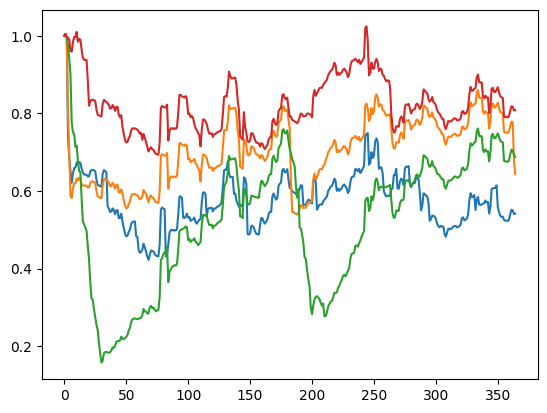

In [ ]:
timesteps = np.array(range(0, runresults['time']['end_time']))
ems_cm = np.array(runresults['cm']['emission timeseries']) / runresults['Null']['emission timeseries'][0]
ems_pln = np.array(runresults['plane']['emission timeseries']) / runresults['Null']['emission timeseries'][0]
ems_ogi = np.array(runresults['ogi']['emission timeseries']) / runresults['Null']['emission timeseries'][0]
ems_null = np.array(runresults['Null']['emission timeseries']) / runresults['Null']['emission timeseries'][0]
plt.plot(timesteps, ems_cm)
plt.plot(timesteps, ems_pln)
plt.plot(timesteps, ems_ogi)
plt.plot(timesteps, ems_null)
plt.show()

Okay, that's good - very basic plot of the emissions timeseries from the modeling. Lets see about functionalizing that? 
First - extremely basic loop to pull out the program names: 

In [ ]:
counter = 0 
for i in runresults.keys():
    print(i)
    counter += 1

cm
ogi
plane
Null
time


Okay, that's good - we can loop over the different programs and pull out the emissions timeseries. I'm adapting the code in the FEAST plotting; lets see how it goes. 
Note: you need to print plt.legend() to get the legend to work. https://stackoverflow.com/questions/11983024/matplotlib-legends-not-working
You do the average plots in a non-array because you only need two points for each line, start and ending. Note that the OG function that pulls from a .p file also sets a color scale and maps the avg emissions to the same color scale as the traces; that's a fixable problem, but not a current priority. This was just to confirm that I understood how the plotting worked and the file structrures. 

cm
ogi
plane
no LDAR


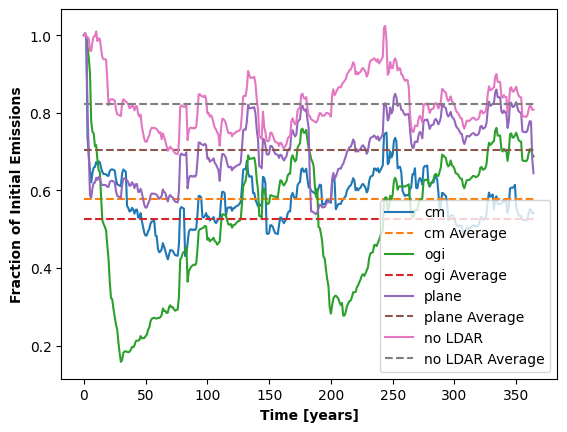

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(111)

 
for i in runresults.keys():
    lab = i #set the legend 
    #skip time and also set null to no LDAR
    if i.lower() == "null":
        lab = "no LDAR"
    if i.lower() == "time":
        break
    print(lab)
    ax.plot(np.array(range(0,runresults['time']['n_timesteps'])), 
            np.array(runresults[i]['emission timeseries']) / runresults["Null"]['emission timeseries'][0], 
            label=lab)
    
    avg_emissions = np.mean(np.array(runresults[i]['emission timeseries'])  / runresults["Null"]['emission timeseries'][0])
    ax.plot([0,runresults['time']['n_timesteps']],np.array([avg_emissions, avg_emissions]), '--', label = lab + ' Average')

    

plt.xlabel('Time [years]', fontweight = 'bold')
plt.ylabel('Fraction of Initial Emissions', fontweight = 'bold')
plt.legend(bbox_to_anchor=(1, 0.72))
plt.legend()

Okay, cool. So we have some plotting abilities here with the timeseries; lets try and sort out some additional ways at getting at this dataset. Lets look in the continuous monitoring subset:  

In [ ]:
runresults["cm"].keys()

dict_keys(['emission timeseries', 'vent timeseries', 'repair cost', 'cm', 'ogi', 'ogi repair'])

Okay - within each "program" you have a series of data; we've already pulled out the emissions timeseries. The Vent time series isn't applicable here; but that will be filled in with "non-repairable" boolean on the emitters. So I was slightly wrong; we CAN do some intermittancy on the large emissions, but you have to get at it through that components piece. 

In [ ]:
timesteps = np.array(range(0, runresults['time']['end_time']))
cm_rc = np.array(runresults['cm']['ogi repair']['repair cost'])

Okay - can't do much with that repair cost as-is right now, because I don't understand the structure. So - Lets pull the built in function for this, and see what it outputs; there is a results_analysis_json function. Pulled code snippet from tutorial notebook, modified to point at a folder with a single json file; but the function is designed to generate results from a folder with a bunch of results from the same scenario. 

In [10]:
ra = feast.ResultsProcessing.results_analysis_functions.results_analysis_json
npv, em_timeseries, programs = ra('TutorialResults', gas_price=0, discount_rate=0)



This is generating: NVP - array of null-nvp (k$/well) (net value present; calling on a subfubction); emissions timeseries - array of emissions in each program in each realization at each time step (checks out, need to sort out loading); costs? (i don't think it is, no, but I see costs in the function); Techs - the program names ie ogi, plane, etc. Something to note - in the FEAST modeling there has to be a Null program, named Null, for this caluclation to work; the calcualtion is in comparison to that program. Sopmething else to note for me: they're flipping this over from how I like to think about it in R; it's 4 rows (one for each program) and 365 columns. 

In [24]:
em_timeseries[2]
# plt.plot(timesteps, em_timeseries[0])
# plt.plot(timesteps, ems_cm)
#^These are the same; so - the results analysis is taking the JSON files and restrutcuting them in to an easier to access format.


array([[26.01010808],
       [26.12924289],
       [25.92562094],
       [20.95565773],
       [18.04931712],
       [15.26870006],
       [15.13531352],
       [15.76302131],
       [16.11314132],
       [16.12936928],
       [16.45974858],
       [16.3153725 ],
       [16.50509841],
       [16.45170759],
       [16.06563722],
       [15.9753501 ],
       [15.96626908],
       [15.96811062],
       [15.94931537],
       [15.85028796],
       [15.84717344],
       [16.17151606],
       [16.24071681],
       [16.25070536],
       [16.20998138],
       [16.16589407],
       [15.5858919 ],
       [15.24259396],
       [15.20408259],
       [15.15348311],
       [15.12141357],
       [15.96930057],
       [16.37366388],
       [16.42521396],
       [16.34960773],
       [16.28691288],
       [16.147385  ],
       [15.91044073],
       [15.9507674 ],
       [16.15415089],
       [16.0354477 ],
       [15.76108783],
       [16.02153769],
       [16.03808187],
       [15.50149883],
       [15

Okay, we generated json version of the reslutsl analysis; lets run the abatement cost plotter. To Note: this function can be run seperately from calling the analysis results, because this function seperately calls it. 

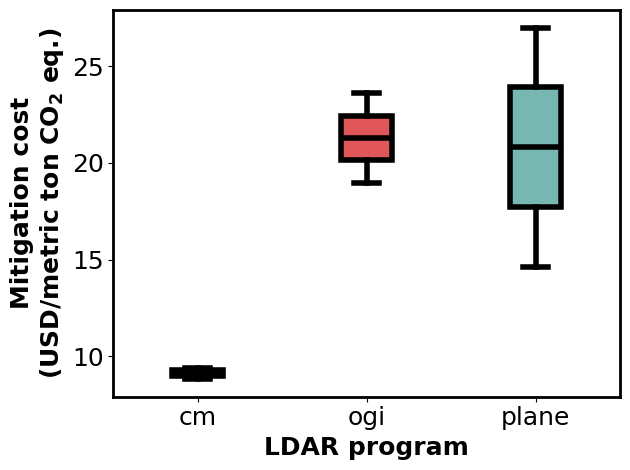

In [25]:
feast.ResultsProcessing.plotting_functions.abatement_cost_plotter_json('TutorialResults', 
                                                                  gwp=34, discount_rate=0, gas_price=0)

Okay, I'm going to work through the abatement cost plotter to make sure I understand it. First - emissions sum calculation , which seems to sum up all emissions in metric tons over the entire run all programs. 

In [ ]:
# emissions = 
np.sum(em_timeseries * runresults['time']['delta_t'] * 3600* 24/1e6)

np.float64(2159.516872907493)

next - they create an "em_abate" and a "cost_abate" matrix of zeros, in the same hape and size of the original emission time series; they drop one of the rows though, which is due to the fact that they're going to do differences against the null result. they're using .shape, which provides the shape of the object in dimensions. [rows, columns, depth]. Note that em_abate in this case is only (3, 365) instead of the original (4,365, 1). I ended up having to fix that; it wouldn't write in the difference values without that 3rd dimension in this version of the code. idk man; seems to work fine in the function but not here in the un-functioned code. 

In [58]:
em_abate = np.zeros([em_timeseries.shape[0] - 1, em_timeseries.shape[1], em_timeseries.shape[2]])
cost_abate = np.zeros([em_timeseries.shape[0] - 1, em_timeseries.shape[1], em_timeseries.shape[2]])

print(em_timeseries.shape)
print(em_abate.shape)


(4, 365, 1)
(3, 365, 1)


In [53]:
em_timeseries.shape[2]

1

Okay, now do the loop; note that the [-1] index puts you at the very last row, which is the NULL case in Feast. noice. 

In [59]:
# ind = 0   
# em_abate[0] = em_timeseries[-1, :] - em_timeseries[ind, :]


for ind in range(em_abate.shape[0]):
        em_abate[ind, :] = em_timeseries[-1, :] - em_timeseries[ind, :]
        cost_abate[ind, :] = -npv['Total'][ind, :]
        
        

so - emissions abatmenet is the difference in emissions per day against the emissions in the null case; the assumption being that null case will have higher values so it's the abatement from the null case (null - program). 

alright, so wtf is the NVP? We have to go back to the results analysis function for that one. Net Present Value: a measure of an assessets value; you calculate present value from the future cash flows that asset will generate. the value depends on the length of time, as you include a time dependent discount on inflows to account for inflation. So for instance - you loan 0.99, with a dollar coming in in one month; over that interval the value is one cent, but if you calcualte out over a long period of time that value will drop because of inflation (the dollar loses value in the future compared to now). 

In [61]:
import pandas as pd


In [73]:
em = pd.read_pickle(f"TutorialResults/realization0_emissionsDataFrame.p")
em.keys()

Index(['flux', 'site_index', 'comp_index', 'reparable', 'end_time',
       'repair_cost', 'start_time'],
      dtype='object')

Ooookay, so its not actually an issue with the pickle reader we pull, it's that pickling dumps very specifically whatever the object is to serialization, and for the FEAST case it's not an object that I can easily use, rather it;s a feast specific object. Using pickle load on the json associated emission dataframe gives you a totally manageable object, vs. loading in an .p realization from the save=pickle runs. 

In [ ]:
# Check = pd.read_pickle(f"TutorialResults/realization3.p")
# Checks = load(open("TutorialResults/realization3.p", 'rb'))

# Check = pd.read_pickle(f"TutorialResults/realization0_emissionsDataFrame.p")
# Checks = load(open("TutorialResults/realization0_emissionsDataFrame.p", 'rb'))


In [82]:
len(pd.unique(em['site_index']))

100

alrtight, that's all fine - something to note though is that we have a file from the JSON data that is providing a bunch of underlying data that is useful. for instance: site index - unique sites. Comp index - unique components. Flux, fixable, start time, end time of the emission, and the repair cost. 

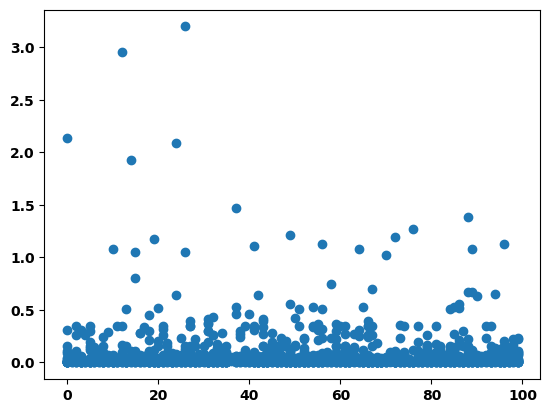

In [85]:
plt.plot(em['site_index'], em['flux'], 'o')

In [86]:
# hmhmmh...
em["leak_length"] = em["end_time"] - em["start_time"]

Cool, okay - you can work with dataframes just fine, includeding element wise makeing new ones., 

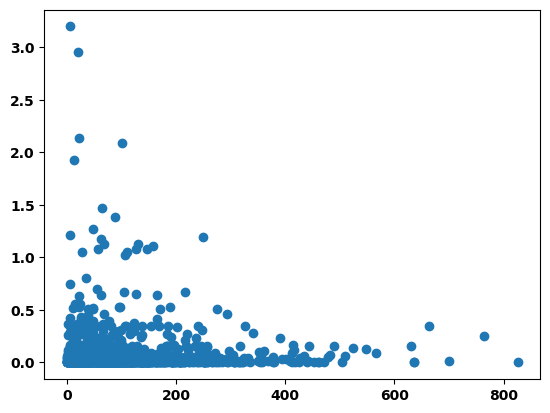

In [88]:
plt.plot(em['leak_length'], em['flux'], 'o' )

Cooooool. I'm going to install and try a quick module for doing ggplot style plots; plotnine

In [90]:
from plotnine import ggplot, geom_point, aes, stat_smooth, facet_wrap
from plotnine.data import mtcars

ModuleNotFoundError: No module named 'plotnine'